# AG-HYPOPT · Trial 02

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

One trial is registered: **trial_01**, objective **0.1127 +/- 0.0825** (the current best). Config `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968`; 0 diverged cells.

Results of trial_01: mu rel-RMSE 77.1% (bias -4.1), gamma rel-RMSE 21.5% (bias -1.4). gamma is accurate at high T (T100 within ~0.7% at 1nW and ~0.2% at 3nW) and degrades only at low T (T05 -44.6% / -29.2%, T20 -26.6% / -8.7%). mu overshoots strongly at mid transmission (1nW T20 +157%, 3nW T05 +137%) and undershoots at high transmission (3nW T60 -23%, 3nW T100 -38%), while 1nW T60/T100 are near-perfect (-1.3%, -4.7%).

The registry still holds only this one entry, and cell 2 reports `phase = uniform` (1/5 trials): the campaign is still in its uninformed uniform-exploration phase, drawing candidates from the raw search space with no expected-improvement values. The objective is the T-weighted mean of capped rel-sq errors over the 8-experiment benchmark, so the high-T half of the mu error (where mu currently undershoots) carries the most weight.

Schedule convention (from `ag_hypopt.py`): `lr_mu(t) = lr_mu*(1 - mu_anneal*t/n_iter)`, and likewise for gamma, so `lr_mu` and `mu_anneal` jointly set the total mu travel over the 30 iterations, and `mu_anneal -> 1` decays the step to zero before the end.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_02'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.23545092082438476, "lr_gamma": 0.3335665862434171, "lr_mu": 0.4080417415941688, "mu_anneal": 0.0919159421350969}
 2 |      - | {"gamma_anneal": 0.5400904733690887, "lr_gamma": 0.7421325004712049, "lr_mu": 0.09801103131646871, "mu_anneal": 0.05514662733306819}
 3 |      - | {"gamma_anneal": 0.2474724311154343, "lr_gamma": 0.674561364131813, "lr_mu": 0.2833215030763119, "mu_anneal": 0.15006226330533612}
 4 |      - | {"gamma_anneal": 0.38936771172430845, "lr_gamma": 0.6858324336457943, "lr_mu": 0.21427841326871327, "mu_anneal": 0.6331843992741164}
 5 |      - | {"gamma_anneal": 0.870692357244309, "lr_gamma": 0.698911581194144, "lr_mu": 0.19885429237461294, "mu_anneal": 0.18725256972009807}
 6 |      - | {"gamma_anneal": 0.3113645990145598, "lr_gamma": 0.5355126748910982, "lr_mu": 0.44614865770278667, "mu_anneal": 0.7755639424726894}
 7 |      - | {"gamma_anneal": 0.28633194055383693, "lr_gamma": 0.9280060

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Only one trial is recorded (trial_01, objective 0.1127) and cell 2 is still in the `uniform` phase (1/5), so there are still no expected-improvement values to rank candidates by; the choice is an exploration decision informed by what trial_01 showed.

trial_01 gives a clear picture: **mu is the dominant error**, gamma is already good wherever there is enough signal. The gamma side of trial_01 (moderate-high `lr_gamma=0.80`, low `gamma_anneal=0.30`) produced no divergence and near-perfect high-T gamma, so the gamma knobs are in a reasonable region. The mu side is where the objective is lost: it undershoots at the heavily-weighted high-T cells (3nW T60/T100) and overshoots at the unweighted-to-lightly-weighted low/mid-T cells.

With the schedule `lr_mu(t) = lr_mu*(1 - mu_anneal*t/n_iter)`, mu travel is governed jointly by `lr_mu` and `mu_anneal`. The most informative next probe is therefore to increase the *sustained* mu travel (higher `lr_mu` combined with a much smaller `mu_anneal`, so the step does not decay away early) while keeping the gamma knobs in the region that already worked in trial_01. Reading the candidates:
- candidate 3: `lr_mu=0.283` (~1.8x trial_01), `mu_anneal=0.150` (much less mu-LR decay), `lr_gamma=0.675`, `gamma_anneal=0.247` — more sustained mu movement, gamma region close to trial_01.
- candidate 1: `lr_mu=0.408`, `mu_anneal=0.092` — even more mu travel; more aggressive.
- candidate 9: `lr_mu=0.324`, `mu_anneal=0.407`, `lr_gamma=0.857`, `gamma_anneal=0.612` — higher gamma anneal, i.e. two things changed at once.
- candidate 10: `lr_mu=0.432`, `mu_anneal=0.438` — higher mu LR but keeps a fast decay.
- candidate 2: `lr_mu=0.098` — less mu travel than trial_01 (tests the opposite direction but contradicts the high-T undershoot).

Candidate 3 is the cleanest single-axis probe: it moves the mu schedule decisively toward sustained (larger, less-decayed) movement while leaving the gamma schedule near the configuration that already kept gamma finite and accurate at high T. That makes it more informative than candidate 9 or 10, which change the gamma handling at the same time.

I choose candidate 3 (3 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.2474724311154343, 'lr_gamma': 0.674561364131813, 'lr_mu': 0.2833215030763119, 'mu_anneal': 0.15006226330533612}
Running  1nW Trans05 ... 

μ 9.39 -> 7.28 | γ 8.5 -> -2.20 | NLL 1.28


Running  1nW Trans20 ... 

μ 17.32 -> 61.80 | γ 8.5 -> 6.38 | NLL 5.79


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 95.38 | γ 14.1 -> 14.95 | NLL 3.55


Running 3nW Trans100 ... 

μ 175.71 -> 124.92 | γ 14.1 -> 13.98 | NLL 3.35



Total: 6.6 min


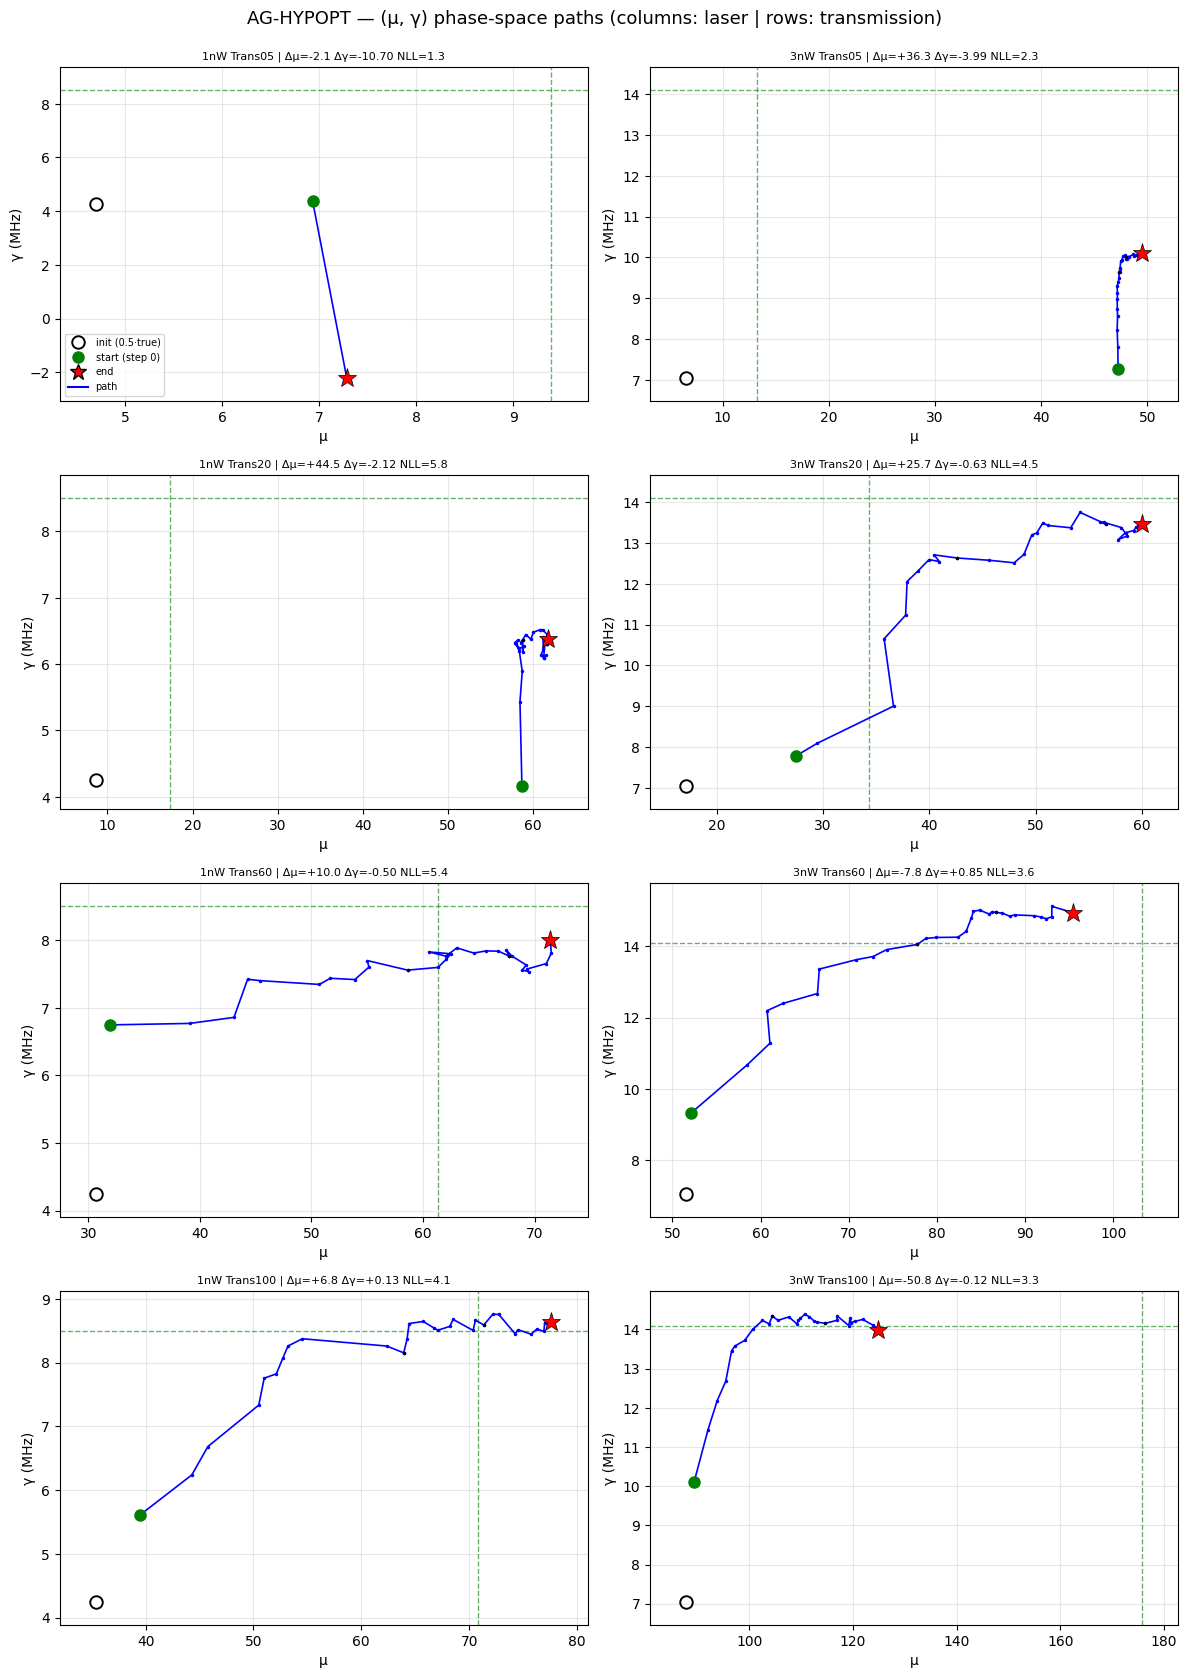

trial finished in 6.7 min
objective = 0.1449 ± 0.0998
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    7.28   -22.5 |     8.50   -2.20  -125.9
1nW Trans20       17.32   61.80  +256.9 |     8.50    6.38   -25.0
1nW Trans60       61.37   71.40   +16.3 |     8.50    8.00    -5.9
1nW Trans100       70.82   77.62    +9.6 |     8.50    8.63    +1.5
3nW Trans05       13.20   49.46  +274.6 |    14.10   10.11   -28.3
3nW Trans20       34.28   59.97   +74.9 |    14.10   13.47    -4.4
3nW Trans60      103.20   95.38    -7.6 |    14.10   14.95    +6.0
3nW Trans100      175.71  124.92   -28.9 |    14.10   13.98    -0.9

weighted objective (T-graded, cap=1.0) = 0.1449 | diverged cells: 1
μ: RMSE 29.037 (rel 136.4%, bias +7.817) | γ: RMSE 4.130 (rel 46.6%, bias -2.137)


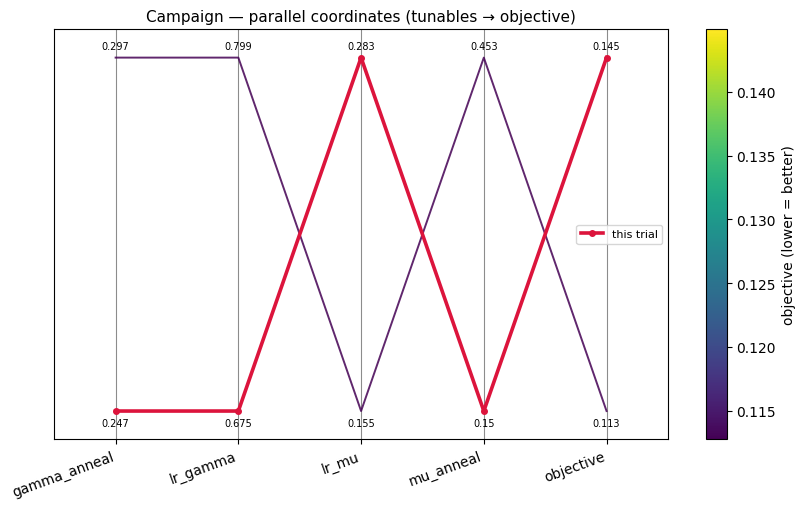

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 02 ran candidate 3: `lr_mu=0.2833`, `mu_anneal=0.1501`, `lr_gamma=0.6746`, `gamma_anneal=0.2475`. It completed in 6.7 min (100x30) with objective **0.1449 +/- 0.0998** and **1 diverged cell** (1nW T05: gamma went to -2.20, outside the [0.02, 500] guard band). This is **worse** than trial_01 (0.1127).

Aggregate accuracy: **mu rel-RMSE 136.4%** (RMSE 29.04, bias +7.82) vs 77.1% in trial_01; **gamma rel-RMSE 46.6%** (RMSE 4.13, bias -2.14) vs 21.5% in trial_01. Both channels degraded.

Per-cell relative errors:
- **mu:** 1nW T05 -22.5% (diverged), T20 **+256.9%**, T60 +16.3%, T100 +9.6% | 3nW T05 **+274.6%**, T20 +74.9%, T60 -7.6%, T100 -28.9%.
- **gamma:** 1nW T05 **-125.9%** (diverged, gamma -2.20), T20 -25.0%, T60 -5.9%, T100 +1.5% | 3nW T05 -28.3%, T20 -4.4%, T60 +6.0%, T100 -0.9%.

Comparison with trial_01: the single intended change was more *sustained* mu travel (lr_mu 0.155 -> 0.283, mu_anneal 0.454 -> 0.150, so the mu step decays much less), with the gamma knobs left near trial_01's region (lr_gamma 0.799 -> 0.675, gamma_anneal 0.297 -> 0.248). The result went the wrong way: the mid/low-T mu overshoot grew sharply (1nW T20 +157% -> +257%; 3nW T05 +137% -> +275%), the 1nW high-T cells flipped from undershoot to overshoot (+9.6% / +16.3%), and the 3nW T100 undershoot barely improved (-38.1% -> -28.9%). A gamma divergence also appeared at 1nW T05 that trial_01 did not have. So the larger-travel mu schedule is clearly the worse of the two on this benchmark.

**Summary:** Trial 02 (lr_mu=0.2833, mu_anneal=0.1501, lr_gamma=0.6746, gamma_anneal=0.2475): objective 0.1449 +/- 0.0998 with 1 diverged cell (1nW T05, gamma -2.20); more sustained mu travel worsened every mu error (rel-RMSE 77% -> 136%, mid/low-T overshoot up to +275%) versus trial_01.
**Key insight:** Increasing sustained mu travel (higher lr_mu, lower mu_anneal) is the wrong direction on this benchmark: it aggravates the mid/low-T mu overshoot and additionally induced a low-T gamma divergence, so the smaller-travel mu schedule of trial_01 is preferred.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The 1nW T05 gamma divergence appeared here with *more* mu travel even though lr_gamma was slightly lower than trial_01 — consistent with the low-count gamma noise/freeze failure mode being driven by the mu trajectory as much as by the gamma step (a larger mu overshoot changes the sigma_fit landscape the gamma gradient sits on). If later trials cannot suppress both the mid/low-T mu overshoot and the high-T mu undershoot with global schedule knobs, a mu step size adapted to n_target (or a per-transmission schedule) is the structural candidate; recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 02 (lr_mu=0.2833, mu_anneal=0.1501, lr_gamma=0.6746, gamma_anneal=0.2475): objective 0.1449 +/- 0.0998 with 1 diverged cell (1nW T05, gamma -2.20); more sustained mu travel worsened every mu error (rel-RMSE 77% -> 136%, mid/low-T overshoot up to +275%) versus trial_01"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Increasing sustained mu travel (higher lr_mu, lower mu_anneal) is the wrong direction on this benchmark: it aggravates the mid/low-T mu overshoot and additionally induced a low-T gamma divergence, so the smaller-travel mu schedule of trial_01 is preferred"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_02 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_03.ipynb. Open it and follow its cells from the top.
